# Volatility Project 02 — Time-Series Model Ladder

## The question

Can a compact, leakage-aware workflow turn one financial-style series into a forecast that beats an honest naive benchmark? This notebook is designed for the middle two to three hours of a 4–6 hour onsite: diagnose first, build only causal features, compare every candidate on identical expanding-window folds, and keep the baseline when complexity does not earn its place.

The default demo predicts the next observed return from information available at the current close. Replace one tagged data cell for a real task. The 20% tail holdout stays sealed until the OOF comparison has selected a candidate.

In [1]:
import os, platform, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.Series({"python": platform.python_version(), "numpy": np.__version__,
           "pandas": pd.__version__, "sklearn": sklearn.__version__}, name="version")

python     3.12.0
numpy       2.5.2
pandas      2.3.3
sklearn     1.8.0
Name: version, dtype: object

## Parameters

These are the only knobs needed for the default path. `TARGET_HISTORY_AVAILABLE=False` is deliberate because batch test sets normally do not reveal earlier test labels: computing a target shift would use hidden truth or stop working after the first test row. Set it true only when the organizer explicitly supplies the released lag at prediction time. Set `FORCE_SKLEARN_BOOSTER=True`—or export `VOLATILITY_TS_FORCE_SKLEARN_BOOSTER=1`—to test the dependency-free nonlinear branch.

In [2]:
USE_DEMO = True
TRAIN_PATH = None
TEST_PATH = None
SAMPLE_SUBMISSION_PATH = None
TIME_COL, TARGET_COL = "date", "next_return"
ID_COLS = (TIME_COL,)
LABEL_HORIZON = 1
TARGET_HISTORY_AVAILABLE = False
DATE_COL, ID_COL, HORIZON = TIME_COL, ID_COLS[0], LABEL_HORIZON  # concise aliases below
PRICE_COL = "close"
PREDICTION_COL = "prediction"
N_TRAIN, N_TEST = 720, 60
PURGE_GAP = LABEL_HORIZON
LAGS, ROLL_WINDOWS = (1, 2, 5, 10), (5, 20, 60)
FINAL_HOLDOUT_FRACTION = 0.20
N_SPLITS, RIDGE_ALPHA = 5, 10.0
N_TREES, SEED = 220, 42
TARGET_RELEASE_DELAY = 1
TARGET_LAG_COL = "known_target_lag"
FORCE_SKLEARN_BOOSTER = False
FORCE_SKLEARN_BOOSTER |= os.getenv("VOLATILITY_TS_FORCE_SKLEARN_BOOSTER", "0") == "1"
WRITE_SUBMISSION = False
SUBMISSION_PATH = "volatility_project_02_submission.csv"

## Where the data comes from

The demo is deterministic and financial in shape: persistent observable states drive a noisy next-day return through both linear and nonlinear effects. It includes mild missingness and a chronological test block. For a real case, set `USE_DEMO=False` and provide train, test, and sample-submission CSV paths; the test file must not contain the target.

In [3]:
if USE_DEMO:
    rng = np.random.default_rng(SEED)
    n_total = N_TRAIN + N_TEST + HORIZON
    flow, risk = np.zeros(n_total), np.zeros(n_total)
    state_noise = rng.normal(size=(n_total, 2))
    for t in range(1, n_total):
        flow[t] = 0.82 * flow[t - 1] + 0.55 * state_noise[t, 0]
        risk[t] = 0.94 * risk[t - 1] + 0.25 * state_noise[t, 1]
    realized = np.zeros(n_total)
    return_noise = rng.standard_t(df=7, size=n_total)
    for t in range(n_total - 1):
        nonlinear = 0.0025 * np.tanh(1.4 * flow[t]) + 0.002 * (flow[t] > 0.8) * (risk[t] > 0)
        sigma = 0.006 * (1.0 + 0.25 * np.clip(risk[t], -1.5, 2.5))
        realized[t + 1] = 0.12 * realized[t] + 0.0015 * flow[t] - 0.0008 * risk[t] + nonlinear + sigma * return_noise[t + 1]
    dates = pd.bdate_range("2018-01-02", periods=n_total)
    close = 100.0 * np.exp(np.cumsum(realized))
    volume = rng.lognormal(13.0 + 0.18 * risk + 5.0 * np.abs(realized), 0.35)
    raw = pd.DataFrame({DATE_COL: dates, PRICE_COL: close, "volume": volume, "flow": flow, "risk_index": risk})
    raw[TARGET_COL] = pd.Series(realized).shift(-HORIZON).to_numpy()
    raw[TARGET_LAG_COL] = realized  # equals the released prior label only for this horizon-1 demo
    missing = rng.random((n_total, 2)) < np.array([0.025, 0.015])
    raw.loc[missing[:, 0], "flow"], raw.loc[missing[:, 1], "volume"] = np.nan, np.nan
    train = raw.iloc[:N_TRAIN].copy()
    test = raw.iloc[N_TRAIN:N_TRAIN + N_TEST].drop(columns=TARGET_COL).copy()
    sample_submission = test[[ID_COL]].assign(**{PREDICTION_COL: 0.0})
else:
    required = {"TRAIN_PATH": TRAIN_PATH, "TEST_PATH": TEST_PATH,
                "SAMPLE_SUBMISSION_PATH": SAMPLE_SUBMISSION_PATH}
    if any(value is None for value in required.values()):
        raise ValueError(f"Set every real-data path: {required}")
    train, test = pd.read_csv(TRAIN_PATH), pd.read_csv(TEST_PATH)
    sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)
    train[DATE_COL], test[DATE_COL] = pd.to_datetime(train[DATE_COL]), pd.to_datetime(test[DATE_COL])
    if ID_COL == DATE_COL:
        sample_submission[ID_COL] = pd.to_datetime(sample_submission[ID_COL])
print(f"train={train.shape}, test={test.shape}, demo={USE_DEMO}")

train=(720, 7), test=(60, 6), demo=True


## Recipes in this notebook

| Recipe | Interview decision |
|---|---|
| [R11.1](#r11-1) | Validate the time axis and seal the final tail |
| [R11.2](#r11-2) | Diagnose missingness, drift, and the development target |
| [R11.3](#r11-3) | Build causal lags and rolling features |
| [R11.4](#r11-4) | Construct purged expanding folds |
| [R11.5](#r11-5) | Establish fold-local mean and observable-lag baselines |
| [R11.6](#r11-6) | Put Ridge and the nonlinear model in fitted pipelines |
| [R11.7](#r11-7) | Produce predictions on identical OOF rows |
| [R11.8](#r11-8) | Score the ladder and retain the baseline honestly |
| [R11.9](#r11-9) | Diagnose residuals after CV |
| [R11.10](#r11-10) | Open the holdout once, refit, and make a submission |

## Things to watch

**Python and pandas.** Sort before every shift; keep train and test dtypes aligned; let fitted imputers learn inside folds; remember that `TimeSeriesSplit.gap` counts rows here because this notebook has one row per timestamp.

**Analysis.** A lagged target is a feature only after its label-release delay; a future covariate is not available merely because it is present in the file; pooled OOF error can hide a disastrous fold; test data may be inspected for schema and covariate drift, never for labels.

## Diagnose before modelling

<a id="r11-1"></a>
## R11.1 · Validate the clock and seal the last 20%

**Topic** Validation design

**Use when** observations have a natural order and the final check must resemble deployment.

**Inputs** `train`, `test`, the time/target names, purge gap, and holdout fraction.

**Needs** None.

**Gotchas** seal by distinct timestamps before target-aware exploration; parsing dates after sorting can create a lexical chronology.

**See also** [R11.4](#r11-4) for the inner expanding folds.

In [4]:
train, test = train.sort_values(DATE_COL).reset_index(drop=True), test.sort_values(DATE_COL).reset_index(drop=True)
assert TARGET_COL in train and TARGET_COL not in test, "target boundary is broken"
assert train[DATE_COL].is_monotonic_increasing and test[DATE_COL].is_monotonic_increasing
assert not train[DATE_COL].duplicated().any(), "this template expects one row per timestamp"
assert train[DATE_COL].max() < test[DATE_COL].min(), "test must be strictly later than train"
train_dates = pd.Index(train[DATE_COL].drop_duplicates())
n_holdout_dates = max(1, int(np.ceil(len(train_dates) * FINAL_HOLDOUT_FRACTION)))
development_dates = train_dates[:len(train_dates) - n_holdout_dates - PURGE_GAP]
purge_dates = train_dates[len(development_dates):len(train_dates) - n_holdout_dates]
holdout_dates = train_dates[-n_holdout_dates:]
diagnostic_train = train[train[DATE_COL].isin(development_dates)].copy()
checks = pd.Series({"train_rows": len(train), "test_rows": len(test),
                    "development_rows": len(diagnostic_train), "sealed_holdout_rows": n_holdout_dates,
                    "duplicate_times": int(train[DATE_COL].duplicated().sum()),
                    "target_missing_development": int(diagnostic_train[TARGET_COL].isna().sum()),
                    "train_end": train[DATE_COL].max(), "test_start": test[DATE_COL].min()})
display(checks.to_frame("value"))
diagnostic_train[TARGET_COL].describe(percentiles=[0.01, 0.5, 0.99]).to_frame()

,value
train_rows,720
test_rows,60
development_rows,575
sealed_holdout_rows,144
duplicate_times,0
target_missing_development,0
train_end,2020-10-05 00:00:00
test_start,2020-10-06 00:00:00


,next_return
count,575.000000
mean,-0.000070
std,0.008198
min,-0.031096
1%,-0.018067
50%,-0.000203
99%,0.020851
max,0.037260


<a id="r11-2"></a>
## R11.2 · Inspect missingness, drift, and the development target

**Topic** Data quality

**Use when** you need a ten-minute diagnosis that changes modelling choices rather than a decorative EDA tour.

**Inputs** Raw train/test frames and the unsealed development subset.

**Needs** [R11.1](#r11-1).

**Gotchas** train/test drift is descriptive and transductive; do not use hidden test labels or repeatedly tune to the test distribution.

**See also** [R11.9](#r11-9) for diagnostics on genuinely OOF predictions.

,train,test
volume,0.0139,0.0
flow,0.0264,0.0


,train_mean,train_std,test_mean,test_std,mean_shift_train_sd
risk_index,-0.052,0.618,-0.651,0.718,-0.969
close,99.388,8.790,92.164,2.876,-0.822
volume,484152.009,190174.935,395170.781,140830.616,-0.468
flow,-0.086,0.924,0.163,0.966,0.270
known_target_lag,-0.000,0.008,0.001,0.007,0.112


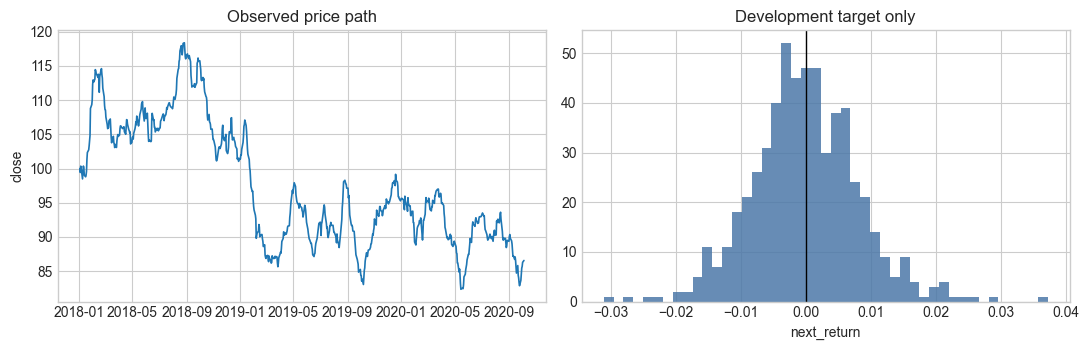

In [5]:
common_numeric = [c for c in train.select_dtypes("number") if c in test and c != TARGET_COL]
train_stats = diagnostic_train[common_numeric].agg(["mean", "std"]).T.add_prefix("train_")
test_stats = test[common_numeric].agg(["mean", "std"]).T.add_prefix("test_")
drift = train_stats.join(test_stats)
drift["mean_shift_train_sd"] = (drift["test_mean"] - drift["train_mean"]) / drift["train_std"].replace(0, np.nan)
missingness = pd.concat({"train": train.isna().mean(), "test": test.isna().mean()}, axis=1)
display(missingness.query("train > 0 or test > 0").sort_values("test", ascending=False).round(4))
display(drift.sort_values("mean_shift_train_sd", key=lambda s: s.abs(), ascending=False).round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(train[DATE_COL], train[PRICE_COL], lw=1.2); axes[0].set(title="Observed price path", ylabel=PRICE_COL)
axes[1].hist(diagnostic_train[TARGET_COL].dropna(), bins=45, color="#4c78a8", alpha=0.85)
axes[1].axvline(0, color="black", lw=1); axes[1].set(title="Development target only", xlabel=TARGET_COL)
fig.tight_layout(); plt.show()

## Build causal evidence

<a id="r11-3"></a>
## R11.3 · Build lags and rolling state from observable history

**Topic** Feature engineering

**Use when** the target is future-facing but current and past market variables are observable.

**Inputs** Sorted raw train/test frames, lag windows, and the optional released-label contract.

**Needs** [R11.1](#r11-1).

**Gotchas** rolling windows below include the current close, which is valid only because prediction occurs after that close; recompute this contract for a pre-close forecast.

**See also** [R11.5](#r11-5) for the last-observed-return baseline.

In [6]:
train_part, test_part = train.assign(_split="train"), test.assign(_split="test")
all_rows = pd.concat([train_part, test_part], ignore_index=True, sort=False).sort_values(DATE_COL).reset_index(drop=True)
all_rows["row_position"] = np.arange(len(all_rows))
all_rows["return_1d"] = all_rows[PRICE_COL].pct_change()
all_rows["log_volume"] = np.log1p(all_rows["volume"].clip(lower=0))
all_rows["volume_change"] = all_rows["log_volume"].diff()
for lag in LAGS:
    all_rows[f"return_lag{lag}"] = all_rows["return_1d"].shift(lag)
for window in ROLL_WINDOWS:
    rolling = all_rows["return_1d"].rolling(window, min_periods=max(3, window // 3))
    all_rows[f"return_mean{window}"], all_rows[f"return_std{window}"] = rolling.mean(), rolling.std()
    all_rows[f"close_to_ma{window}"] = all_rows[PRICE_COL] / all_rows[PRICE_COL].rolling(window).mean() - 1
all_rows["weekday_sin"] = np.sin(2 * np.pi * all_rows[DATE_COL].dt.dayofweek / 5); all_rows["weekday_cos"] = np.cos(2 * np.pi * all_rows[DATE_COL].dt.dayofweek / 5)
feature_cols = ["flow", "risk_index", "return_1d", "log_volume", "volume_change",
                "weekday_sin", "weekday_cos"] + [c for c in all_rows if c.startswith(("return_lag", "return_mean", "return_std", "close_to_ma"))]
if TARGET_HISTORY_AVAILABLE:
    if TARGET_RELEASE_DELAY < HORIZON:
        raise ValueError("target lag is not old enough to be released at prediction time")
    if TARGET_LAG_COL not in train or TARGET_LAG_COL not in test:
        raise KeyError(f"{TARGET_LAG_COL} must be supplied in both train and test")
    feature_cols.append(TARGET_LAG_COL)
model_train = all_rows.query("_split == 'train'").dropna(subset=[TARGET_COL]).reset_index(drop=True)
model_test = all_rows.query("_split == 'test'").reset_index(drop=True)
pd.Series({"features": len(feature_cols), "train_rows": len(model_train), "test_rows": len(model_test),
           "released_target_lag_enabled": TARGET_HISTORY_AVAILABLE})

features                          20
train_rows                       720
test_rows                         60
released_target_lag_enabled    False
dtype: object

<a id="r11-4"></a>
## R11.4 · Make purged expanding folds inside the development period

**Topic** Cross-validation

**Use when** every training observation must precede its validation observation.

**Inputs** Prepared training rows, sealed timestamp sets, split count, and purge gap.

**Needs** [R11.1](#r11-1), [R11.3](#r11-3).

**Gotchas** the purge protects forward labels at the boundary; it need not equal the longest backward-only feature window.

**See also** [R11.7](#r11-7) for the single OOF prediction loop.

In [7]:
development = model_train[model_train[DATE_COL].isin(development_dates)].reset_index(drop=True)
sealed_holdout = model_train[model_train[DATE_COL].isin(holdout_dates)].reset_index(drop=True)
assert len(development) and len(sealed_holdout)
assert development[DATE_COL].max() < sealed_holdout[DATE_COL].min()
splitter = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)
folds = list(splitter.split(development))
fold_rows = []
for fold, (fit_idx, valid_idx) in enumerate(folds):
    train_end = development.iloc[fit_idx][DATE_COL].max()
    valid_start = development.iloc[valid_idx][DATE_COL].min()
    assert train_end < valid_start and not set(fit_idx).intersection(valid_idx)
    fold_rows.append({"fold": fold, "n_train": len(fit_idx), "n_valid": len(valid_idx),
                      "train_end": train_end.date(), "valid_start": valid_start.date(),
                      "row_gap": int(valid_idx.min() - fit_idx.max() - 1)})
fold_table = pd.DataFrame(fold_rows)
display(pd.Series({"development": len(development), "purged_tail_rows": len(purge_dates),
                   "sealed_holdout": len(sealed_holdout)}).to_frame("rows"))
fold_table

,rows
development,575
purged_tail_rows,1
sealed_holdout,144


,fold,n_train,n_valid,train_end,valid_start,row_gap
0,0,99,95,2018-05-18,2018-05-22,1
1,1,194,95,2018-09-28,2018-10-02,1
2,2,289,95,2019-02-08,2019-02-12,1
3,3,384,95,2019-06-21,2019-06-25,1
4,4,479,95,2019-11-01,2019-11-05,1


## Run one honest model ladder

<a id="r11-5"></a>
## R11.5 · Put the naive forecasts on the exact OOF rows

**Topic** Baselines

**Use when** a model score needs an economically meaningful bar rather than comparison with zero.

**Inputs** Development rows and the fixed fold list.

**Needs** [R11.4](#r11-4).

**Gotchas** the mean must be recomputed on each fit fold; the observable lag predicts with the return known at the current close, not a hidden future label.

**See also** [R11.8](#r11-8) for skill measured against the stronger baseline.

In [8]:
y_dev = development[TARGET_COL].to_numpy(dtype=float)
oof_predictions = {"fold_mean": np.full(len(development), np.nan),
                   "last_observed_return": np.full(len(development), np.nan)}
baseline_names = ["fold_mean", "last_observed_return"]
if TARGET_HISTORY_AVAILABLE:
    oof_predictions["released_target_lag"] = np.full(len(development), np.nan)
    baseline_names.append("released_target_lag")
fold_id = np.full(len(development), -1, dtype=int)
for fold, (fit_idx, valid_idx) in enumerate(folds):
    oof_predictions["fold_mean"][valid_idx] = y_dev[fit_idx].mean()
    oof_predictions["last_observed_return"][valid_idx] = development.iloc[valid_idx]["return_1d"]
    if TARGET_HISTORY_AVAILABLE:
        oof_predictions["released_target_lag"][valid_idx] = development.iloc[valid_idx][TARGET_LAG_COL]
    fold_id[valid_idx] = fold
scored_mask = fold_id >= 0
assert all(np.isfinite(oof_predictions[name][scored_mask]).all() for name in baseline_names)
pd.DataFrame({name: pred[scored_mask] for name, pred in oof_predictions.items()}).head()

,fold_mean,last_observed_return
0,0.00084,0.007500
1,0.00084,0.000463
2,0.00084,0.002182
3,0.00084,-0.010292
4,0.00084,-0.015730


<a id="r11-6"></a>
## R11.6 · Keep fitted preprocessing inside Ridge and booster pipelines

**Topic** Pipelines

**Use when** missing-value statistics and scaling must be learned separately in every fold.

**Inputs** Candidate features and the model parameters.

**Needs** [R11.4](#r11-4).

**Gotchas** the fallback is a different algorithm, so report its name; never call it LightGBM in notes or interview conclusions.

**See also** [R11.7](#r11-7) for cloning these pipelines fold by fold.

In [9]:
ridge_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=RIDGE_ALPHA)),
])
if FORCE_SKLEARN_BOOSTER:
    booster = HistGradientBoostingRegressor(max_iter=N_TREES, learning_rate=0.04,
        max_leaf_nodes=15, min_samples_leaf=30, l2_regularization=1.0, random_state=SEED)
    BOOSTER_KEY, BOOSTER_LABEL = "hist_gradient_boosting", "HISTGRADIENTBOOSTING FALLBACK — FORCED"
else:
    try:
        from lightgbm import LGBMRegressor
        booster = LGBMRegressor(n_estimators=N_TREES, learning_rate=0.04, num_leaves=15,
            min_child_samples=30, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            reg_lambda=1.0, random_state=SEED, n_jobs=1, verbosity=-1)
        BOOSTER_KEY, BOOSTER_LABEL = "lightgbm", "LIGHTGBM ACTIVE"
    except (ImportError, OSError) as exc:
        booster = HistGradientBoostingRegressor(max_iter=N_TREES, learning_rate=0.04,
            max_leaf_nodes=15, min_samples_leaf=30, l2_regularization=1.0, random_state=SEED)
        BOOSTER_KEY, BOOSTER_LABEL = "hist_gradient_boosting", f"HISTGRADIENTBOOSTING FALLBACK — {type(exc).__name__}"
booster_pipe = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                         ("model", booster)])
models = {"ridge": ridge_pipe, BOOSTER_KEY: booster_pipe}
print("=" * 72 + f"\nBOOSTER BACKEND: {BOOSTER_LABEL}\n" + "=" * 72)
models

BOOSTER BACKEND: LIGHTGBM ACTIVE


{'ridge': Pipeline(steps=[('impute',
                  SimpleImputer(add_indicator=True, strategy='median')),
                 ('scale', StandardScaler()), ('model', Ridge(alpha=10.0))]),
 'lightgbm': Pipeline(steps=[('impute',
                  SimpleImputer(add_indicator=True, strategy='median')),
                 ('model',
                  LGBMRegressor(colsample_bytree=0.8, learning_rate=0.04,
                                min_child_samples=30, n_estimators=220, n_jobs=1,
                                num_leaves=15, random_state=42, reg_lambda=1.0,
                                subsample=0.8, subsample_freq=1,
                                verbosity=-1))])}

<a id="r11-7"></a>
## R11.7 · Fit every learned model on the same expanding folds

**Topic** Model comparison

**Use when** model comparisons must differ only by estimator, not by validation rows.

**Inputs** Fixed folds, feature list, development frame, and candidate pipelines.

**Needs** [R11.5](#r11-5), [R11.6](#r11-6).

**Gotchas** do not call `cross_val_score` separately with a splitter that may produce different rows; retain the OOF predictions for every later diagnostic.

**See also** [R11.9](#r11-9) for residual checks from this ledger.

In [10]:
X_dev = development[feature_cols]
for name, estimator in models.items():
    prediction = np.full(len(development), np.nan)
    for fit_idx, valid_idx in folds:
        fitted = clone(estimator).fit(X_dev.iloc[fit_idx], y_dev[fit_idx])
        prediction[valid_idx] = fitted.predict(X_dev.iloc[valid_idx])
    oof_predictions[name] = prediction
validation_positions = np.flatnonzero(scored_mask)
assert all(np.array_equal(np.flatnonzero(np.isfinite(p)), validation_positions)
           for p in oof_predictions.values())
oof_ledger = development.iloc[validation_positions][["row_position", DATE_COL]].copy()
oof_ledger["fold"] = fold_id[validation_positions]
oof_ledger["y_true"] = y_dev[validation_positions]
for name, prediction in oof_predictions.items():
    oof_ledger[name] = prediction[validation_positions]
assert oof_ledger["row_position"].is_unique, "each source row must be scored once"
assert oof_ledger[list(oof_predictions)].notna().all(axis=None)
oof_ledger.head()

,row_position,date,fold,y_true,fold_mean,last_observed_return,ridge,lightgbm
100,100,2018-05-22,0,0.000463,0.00084,0.007500,-0.001611,0.004768
101,101,2018-05-23,0,0.002179,0.00084,0.000463,-0.001173,0.001527
102,102,2018-05-24,0,-0.010345,0.00084,0.002182,-0.002500,-0.001605
103,103,2018-05-25,0,-0.015855,0.00084,-0.010292,-0.006036,-0.004051
104,104,2018-05-28,0,0.009572,0.00084,-0.015730,-0.003888,-0.003256


<a id="r11-8"></a>
## R11.8 · Score RMSE, MAE, skill, and the worst fold

**Topic** Model evaluation

**Use when** a single average score could conceal instability or a naive forecast is already strong.

**Inputs** The shared OOF ledger, fold identities, and baseline/model names.

**Needs** [R11.7](#r11-7).

**Gotchas** positive skill means lower RMSE than the strongest baseline on identical rows; it is not an R-squared and is not statistical significance.

**See also** [R11.10](#r11-10) for the untouched-tail check.

In [11]:
def _error_pair(truth, prediction):
    error = np.asarray(truth) - np.asarray(prediction)
    return float(np.sqrt(np.mean(error ** 2))), float(np.mean(np.abs(error)))
fold_metrics = []
for name in oof_predictions:
    for fold, rows in oof_ledger.groupby("fold", sort=True):
        rmse, mae = _error_pair(rows["y_true"], rows[name])
        fold_metrics.append({"candidate": name, "fold": fold, "rmse": rmse, "mae": mae})
fold_scores = pd.DataFrame(fold_metrics)
summary = fold_scores.groupby("candidate").agg(mean_fold_rmse=("rmse", "mean"),
    std_fold_rmse=("rmse", "std"), worst_fold_rmse=("rmse", "max"), mean_fold_mae=("mae", "mean"))
pooled = {name: _error_pair(oof_ledger["y_true"], oof_ledger[name])
          for name in oof_predictions}
summary["oof_rmse"], summary["oof_mae"] = [pooled[n][0] for n in summary.index], [pooled[n][1] for n in summary.index]
best_baseline = summary.loc[baseline_names, "oof_rmse"].idxmin()
summary[f"skill_vs_{best_baseline}"] = 1 - summary["oof_rmse"] / summary.loc[best_baseline, "oof_rmse"]
best_model = summary.loc[list(models), "oof_rmse"].idxmin()
SELECTED_NAME = best_model if summary.loc[best_model, "oof_rmse"] < summary.loc[best_baseline, "oof_rmse"] else best_baseline
score_table = summary.sort_values("oof_rmse")
print(f"selected={SELECTED_NAME}; strongest baseline={best_baseline}; booster={BOOSTER_LABEL}")
score_table.round(6)

selected=ridge; strongest baseline=fold_mean; booster=LIGHTGBM ACTIVE


,mean_fold_rmse,std_fold_rmse,worst_fold_rmse,mean_fold_mae,oof_rmse,oof_mae,skill_vs_fold_mean
candidate,,,,,,,
ridge,0.007506,0.000987,0.008534,0.005594,0.007558,0.005594,0.076956
lightgbm,0.007660,0.001007,0.008904,0.005707,0.007713,0.005707,0.058048
fold_mean,0.008132,0.001068,0.009175,0.006237,0.008188,0.006237,0.000000
last_observed_return,0.009753,0.001531,0.011865,0.007440,0.009849,0.007440,-0.202773


## Diagnose after cross-validation

<a id="r11-9"></a>
## R11.9 · Ask where the OOF errors came from

**Topic** Model diagnostics

**Use when** the headline metric is known and you need to find bias, tails, regimes, or a failing period.

**Inputs** Selected OOF predictions, fold scores, dates, and an observable risk state.

**Needs** [R11.8](#r11-8).

**Gotchas** diagnose OOF residuals, not fitted residuals; observations are already chronological here, so residual autocorrelation has a time-series meaning.

**See also** [R11.2](#r11-2) for the pre-model data diagnosis.

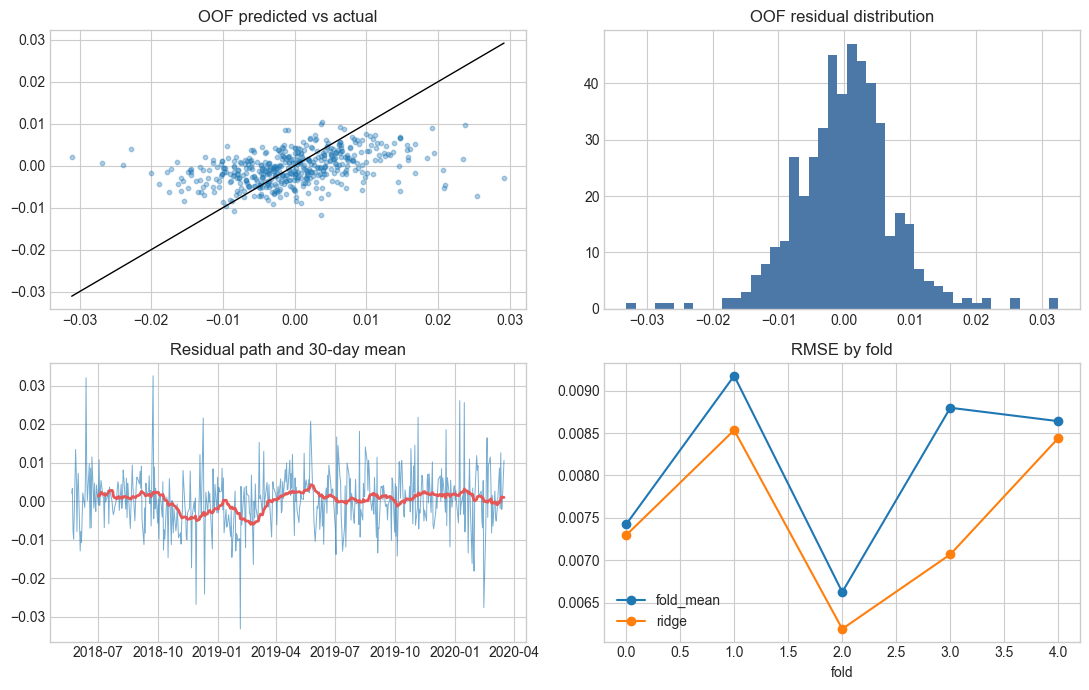

,n,bias,mae,target_std,rmse
risk_quartile,,,,,
"(-1.6139999999999999, -0.457]",119,0.000344,0.005027,0.007525,0.006741
"(-0.457, -0.0343]",119,0.000209,0.005053,0.007426,0.006812
"(-0.0343, 0.382]",118,-0.000671,0.005618,0.007785,0.006844
"(0.382, 1.946]",119,0.001023,0.006680,0.009573,0.009472


oof_bias              0.000228
residual_lag1_corr    0.049926
p95_absolute_error    0.014486
dtype: float64

In [12]:
diag = oof_ledger[["row_position", DATE_COL, "fold", "y_true", SELECTED_NAME]].rename(
    columns={"y_true": "truth", SELECTED_NAME: "prediction"}).copy()
diag["risk_index"] = diag["row_position"].map(development.set_index("row_position")["risk_index"])
diag["residual"] = diag["truth"] - diag["prediction"]
diag["abs_error"] = diag["residual"].abs()
diag["risk_quartile"] = pd.qcut(diag["risk_index"], 4, duplicates="drop")
by_risk = diag.groupby("risk_quartile", observed=True).agg(
    n=("residual", "size"), bias=("residual", "mean"),
    mae=("abs_error", "mean"), target_std=("truth", "std"))
by_risk["rmse"] = diag.groupby("risk_quartile", observed=True)["residual"].apply(lambda s: np.sqrt(np.mean(s ** 2)))
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].scatter(diag["truth"], diag["prediction"], s=10, alpha=0.35)
limits = [diag[["truth", "prediction"]].min().min(), diag[["truth", "prediction"]].max().max()]
axes[0, 0].plot(limits, limits, color="black", lw=1); axes[0, 0].set(title="OOF predicted vs actual")
axes[0, 1].hist(diag["residual"], bins=45, color="#4c78a8"); axes[0, 1].set(title="OOF residual distribution")
axes[1, 0].plot(diag[DATE_COL], diag["residual"], lw=0.7, alpha=0.6)
axes[1, 0].plot(diag[DATE_COL], diag["residual"].rolling(30).mean(), color="#e45756", lw=2); axes[1, 0].set(title="Residual path and 30-day mean")
for name in dict.fromkeys([best_baseline, SELECTED_NAME]):
    path = fold_scores.query("candidate == @name"); axes[1, 1].plot(path["fold"], path["rmse"], marker="o", label=name)
axes[1, 1].set(title="RMSE by fold", xlabel="fold"); axes[1, 1].legend()
fig.tight_layout(); plt.show()
display(by_risk.round(6))
pd.Series({"oof_bias": diag["residual"].mean(), "residual_lag1_corr": diag["residual"].autocorr(),
           "p95_absolute_error": diag["abs_error"].quantile(0.95)})

<a id="r11-10"></a>
## R11.10 · Open the tail once, then refit and shape the submission

**Topic** Inference

**Use when** model selection is finished and one untouched chronological estimate is required before delivery.

**Inputs** Locked candidate name, development/holdout/test frames, pipelines, and sample submission.

**Needs** [R11.8](#r11-8).

**Gotchas** do not return to selection after seeing the tail; refit the locked candidate on all labelled rows and preserve the sample submission's row order exactly.

**See also** [R11.1](#r11-1) for how this tail was sealed.

In [13]:
def _predict_candidate(name, fit_frame, predict_frame):
    if name == "fold_mean":
        return np.full(len(predict_frame), fit_frame[TARGET_COL].mean())
    if name == "last_observed_return":
        return predict_frame["return_1d"].to_numpy()
    if name == "released_target_lag":
        return predict_frame[TARGET_LAG_COL].to_numpy()
    fitted = clone(models[name]).fit(fit_frame[feature_cols], fit_frame[TARGET_COL])
    return fitted.predict(predict_frame[feature_cols])
holdout_names = list(dict.fromkeys([best_baseline, SELECTED_NAME]))
holdout_rows = []
for name in holdout_names:
    prediction = _predict_candidate(name, development, sealed_holdout)
    rmse, mae = _error_pair(sealed_holdout[TARGET_COL], prediction)
    holdout_rows.append({"candidate": name, "holdout_rmse": rmse, "holdout_mae": mae})
holdout_score = pd.DataFrame(holdout_rows).set_index("candidate")
test_prediction = _predict_candidate(SELECTED_NAME, model_train, model_test)
assert len(test_prediction) == len(sample_submission) and np.isfinite(test_prediction).all()
assert sample_submission[ID_COL].reset_index(drop=True).equals(model_test[ID_COL].reset_index(drop=True))
submission = sample_submission.copy()
submission[PREDICTION_COL] = test_prediction
if WRITE_SUBMISSION:
    submission.to_csv(Path(SUBMISSION_PATH), index=False)
display(holdout_score.round(6))
submission.head()

,holdout_rmse,holdout_mae
candidate,,
fold_mean,0.007319,0.005769
ridge,0.006567,0.005144


,date,prediction
720,2020-10-06,-0.003257
721,2020-10-07,-0.004948
722,2020-10-08,-0.005146
723,2020-10-09,0.000083
724,2020-10-12,-0.000220


## Verdict & what carries forward

The deliverable is not ‘LightGBM won.’ It is a traceable decision: a declared timing contract, a sealed 20% tail, causal features, identical purged OOF rows, two naive forecasts, a linear model, one explicitly named nonlinear backend, and diagnostics that show when the score was earned. If neither learned pipeline clears the strongest baseline, `SELECTED_NAME` remains that baseline and the submission still completes.

For an onsite, stop here once the checks are coherent. Add tuning only if the residual and fold diagnostics identify a specific, defensible weakness—and keep that tuning inside the same chronological validation design.